In [2]:
!pip install shap

  Using cached shap-0.49.1-cp310-cp310-win_amd64.whl.metadata (25 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached llvmlite-0.49.0-cp310-cp310-win_amd64.whl.metadata (4.9 kB)
   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 547.0/547.0 kB 1.8 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.8/2.8 MB 2.2 MB/s eta 0:00:01
   ------------------ --------------------- 1.3/2.8 MB 2.2 MB/s eta 0:00:01
   -------------------------- ------------- 1.8/2.8 MB 2.3 MB/s eta 0:00:01
   ------------------------------------- -- 2.6/2.8 MB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 2.6 MB/s  0:00:01
   ----

In [4]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

In [5]:
# Load Module 6 outputs
final_model = joblib.load(
    "../data/outputs/final_model.pkl"
)

X_test_processed = joblib.load(
    "../data/outputs/X_test_processed.pkl"
)

y_test = joblib.load(
    "../data/outputs/y_test.pkl"
)

feature_names = joblib.load(
    "../data/outputs/feature_names.pkl"
)

print("Model loaded successfully.")
print("Test data shape:", X_test_processed.shape)
print("Number of features:", len(feature_names))

Model loaded successfully.
Test data shape: (2400, 77)
Number of features: 77


In [6]:
# Convert processed data to DataFrame
X_test_shap = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

print(X_test_shap.shape)
X_test_shap.head()

(2400, 77)


,num__age,num__num_children,num__family_size,num__annual_income,num__years_employed,num__credit_history_months,num__existing_credit_lines,num__debt_to_income_ratio,num__late_payments_24m,num__has_email,...,cat__product_type_Personal Loan,cat__application_channel_Branch,cat__application_channel_Mobile App,cat__application_channel_Partner,cat__application_channel_Web,cat__application_purpose_Debt Consolidation,cat__application_purpose_Education,cat__application_purpose_Emergency Expense,cat__application_purpose_General Spending,cat__application_purpose_Travel
0,0.587262,-0.745405,-0.363912,-0.094352,0.548392,-0.444862,-1.189946,-0.545281,-0.153545,0.720741,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.446218,0.230176,0.518967,-0.995417,-0.870296,2.437558,-0.338972,-1.741427,-0.153545,0.720741,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,-1.798728,0.230176,-0.363912,0.356181,-0.144063,-1.386829,-1.189946,-1.240477,-0.153545,0.720741,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.064460,1.205757,1.401846,1.398037,0.396390,1.005768,2.213953,1.806119,-0.153545,0.720741,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,1.446218,-0.745405,-1.246791,-0.861665,1.038177,0.346391,0.512003,-1.189360,-0.153545,0.720741,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [7]:
# Create SHAP explainer
explainer = shap.LinearExplainer(
    final_model,
    X_test_shap
)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [8]:
# Calculate SHAP values
shap_values = explainer.shap_values(
    X_test_shap
)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (2400, 77)


In [9]:
# Global feature importance

mean_abs_shap = np.abs(shap_values).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
})

feature_importance = feature_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

feature_importance.head(20)

,Feature,Mean_Absolute_SHAP
7,num__debt_to_income_ratio,0.418729
21,num__dti_percent,0.418729
52,cat__income_type_Working,0.343997
3,num__annual_income,0.304710
4,num__years_employed,0.279430
13,num__monthly_expenses,0.270003
46,cat__own_property_N,0.263644
12,num__monthly_debt_obligation,0.231983
5,num__credit_history_months,0.230291
18,num__disposable_income,0.196509


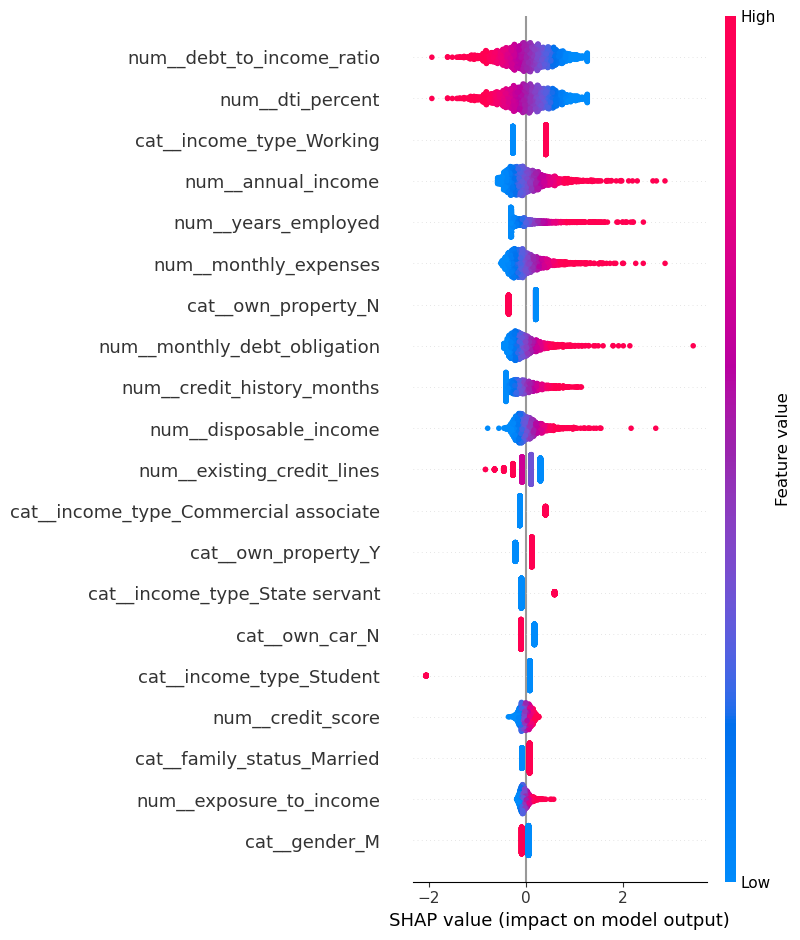

In [10]:
# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_test_shap,
    max_display=20
)

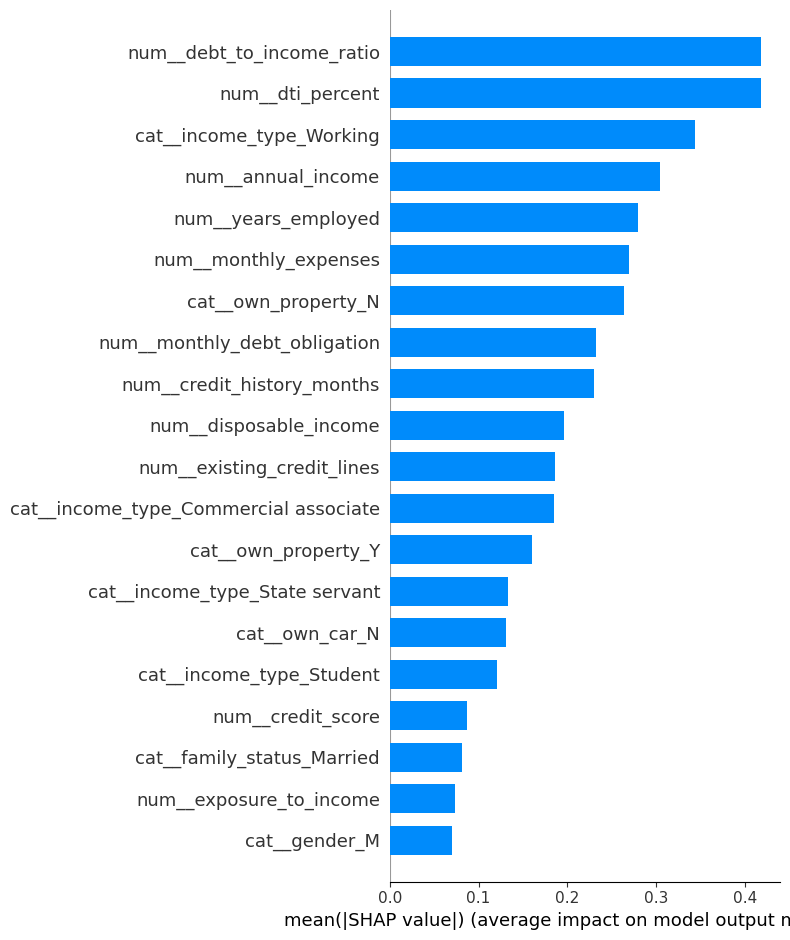

In [11]:
# SHAP bar plot
shap.summary_plot(
    shap_values,
    X_test_shap,
    plot_type="bar",
    max_display=20
)

In [12]:
# Save SHAP feature importance
feature_importance.to_csv(
    "../data/outputs/shap_feature_importance.csv",
    index=False
)

print("SHAP feature importance saved successfully.")

SHAP feature importance saved successfully.


In [13]:
# Individual application explanation
application_index = 0

single_application = X_test_shap.iloc[
    [application_index]
]

single_shap_values = shap_values[
    application_index
]

print("Application index:", application_index)

Application index: 0


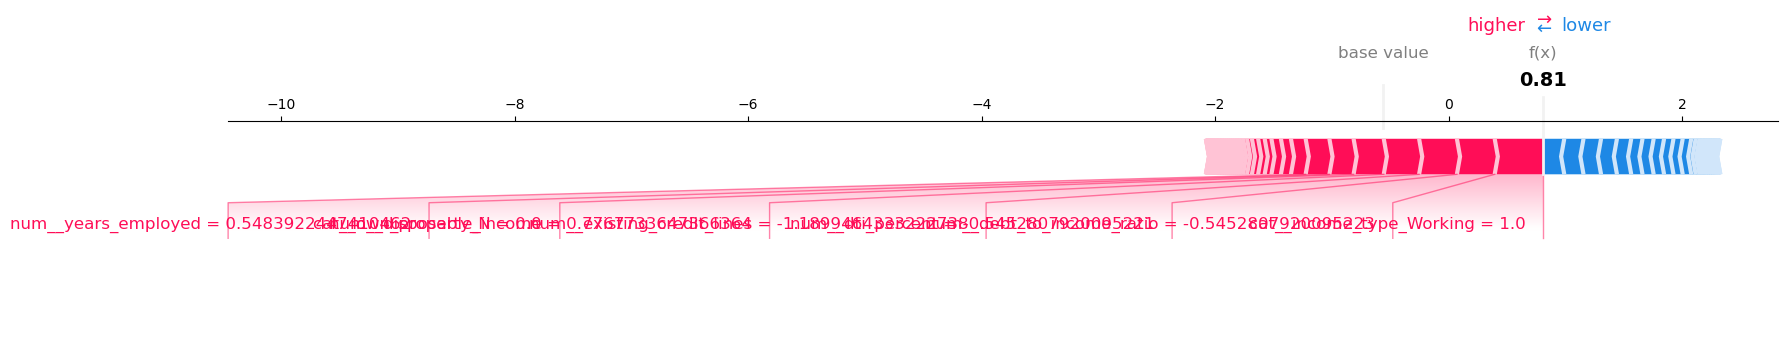

<Figure size 640x480 with 0 Axes>

In [14]:
# Individual SHAP explanation
shap.force_plot(
    explainer.expected_value,
    single_shap_values,
    single_application.iloc[0],
    matplotlib=True
)

plt.tight_layout()
plt.show()

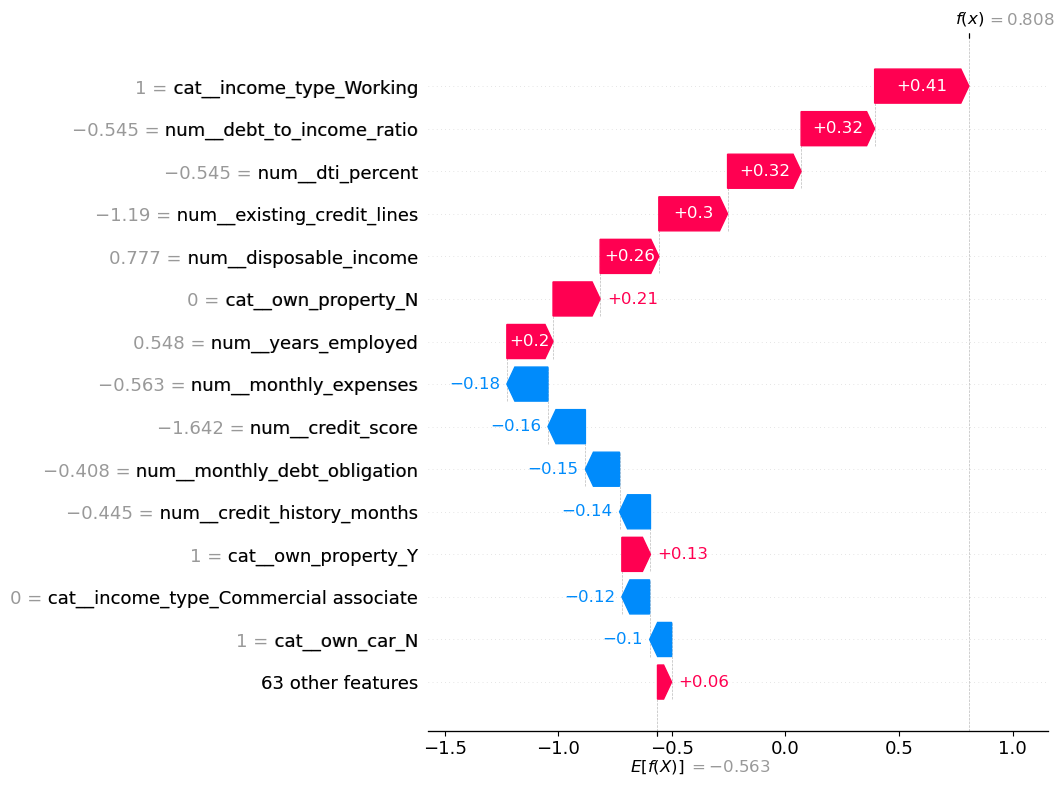

In [15]:
# Waterfall plot
shap_explanation = shap.Explanation(
    values=single_shap_values,
    base_values=explainer.expected_value,
    data=single_application.iloc[0].values,
    feature_names=feature_names
)

shap.plots.waterfall(
    shap_explanation,
    max_display=15
)

In [16]:
# Save SHAP explanation data
single_explanation = pd.DataFrame({
    "Feature": feature_names,
    "Feature_Value": single_application.iloc[0].values,
    "SHAP_Value": single_shap_values
})

single_explanation["Direction"] = np.where(
    single_explanation["SHAP_Value"] > 0,
    "Toward historical approval",
    "Toward historical non-approval"
)

single_explanation = single_explanation.sort_values(
    "SHAP_Value",
    key=abs,
    ascending=False
)

single_explanation.head(15)

,Feature,Feature_Value,SHAP_Value,Direction
52,cat__income_type_Working,1.000000,0.414659,Toward historical approval
7,num__debt_to_income_ratio,-0.545281,0.323682,Toward historical approval
21,num__dti_percent,-0.545281,0.323682,Toward historical approval
6,num__existing_credit_lines,-1.189946,0.302588,Toward historical approval
18,num__disposable_income,0.776773,0.258387,Toward historical approval
46,cat__own_property_N,0.000000,0.207267,Toward historical approval
4,num__years_employed,0.548392,0.203253,Toward historical approval
13,num__monthly_expenses,-0.562723,-0.180932,Toward historical non-approval
17,num__credit_score,-1.642142,-0.164845,Toward historical non-approval
12,num__monthly_debt_obligation,-0.408148,-0.150265,Toward historical non-approval


In [17]:
single_explanation.to_csv(
    "../data/outputs/single_application_shap.csv",
    index=False
)

print("Individual SHAP explanation saved.")

Individual SHAP explanation saved.


In [18]:
feature_importance.head(20)

,Feature,Mean_Absolute_SHAP
7,num__debt_to_income_ratio,0.418729
21,num__dti_percent,0.418729
52,cat__income_type_Working,0.343997
3,num__annual_income,0.304710
4,num__years_employed,0.279430
13,num__monthly_expenses,0.270003
46,cat__own_property_N,0.263644
12,num__monthly_debt_obligation,0.231983
5,num__credit_history_months,0.230291
18,num__disposable_income,0.196509


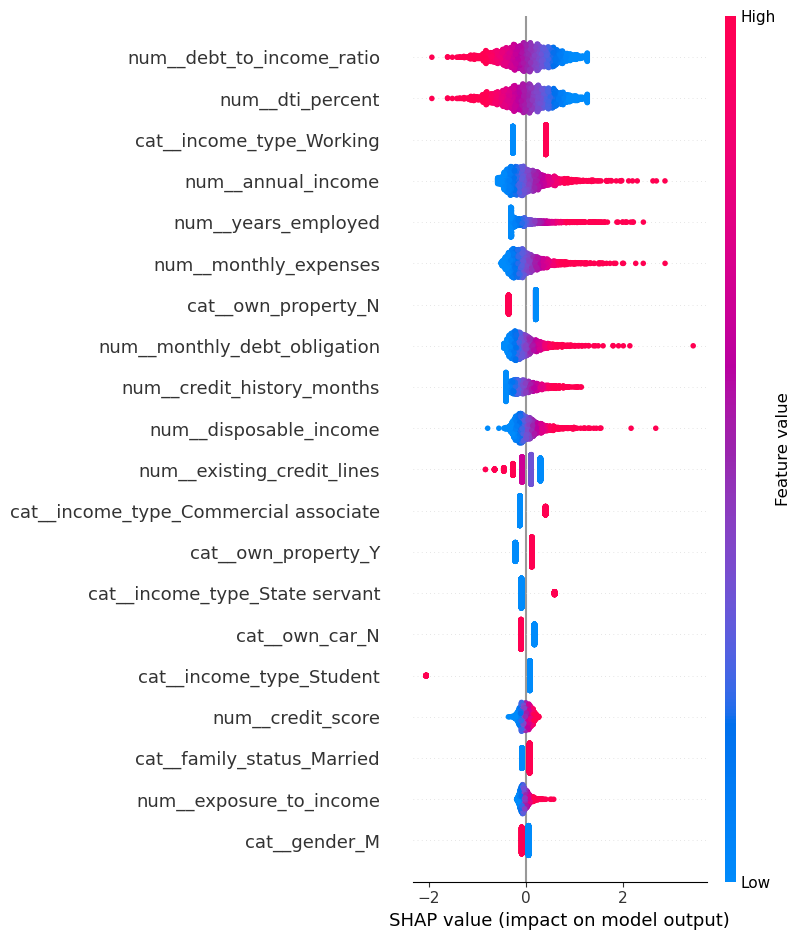

In [19]:
shap.summary_plot(
    shap_values,
    X_test_shap,
    max_display=20
)